# 세션 5 — 챗봇: LCEL, LangGraph, ReAct

같은 검색기를 세 단계로 감쌉니다. 각 단계의 구조를 그림으로 보고 차이를 이해합니다.

1. LCEL — 가장 단순한 RAG 체인 (한 번 묻고 한 번 답)
2. LangGraph — 대화를 기억하는 멀티턴 챗봇
3. ReAct — 검색·계산이 필요한지, 어떤 도구를 쓸지 LLM이 스스로 판단하는 에이전트

검색기는 세션 4에서 가장 좋았던 조합(docling 추출 + Contextual + Rerank)을 그대로 씁니다.
세 챗봇 모두 같은 `retriever` 를 재사용하고, 차이는 검색을 어떻게 엮느냐뿐입니다.

In [2]:
# 준비 셀 — 경로와 API 키 (매 세션 같은 코드로 시작한다)
import os, time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()                            # .env 의 OPENAI_API_KEY 를 환경변수로 등록

ROOT = Path.cwd().parent                 # notebooks/ 의 상위 = 프로젝트 폴더
PDF = ROOT / "data" / "저출생_반전을_위한_대책_관계부처_합동_.pdf"
CACHE = ROOT / "cache"
CACHE.mkdir(exist_ok=True)

print("OpenAI key:", bool(os.getenv("OPENAI_API_KEY")), "| PDF:", PDF.exists())

OpenAI key: True | PDF: True


In [3]:
# 임베딩 모델과 LLM 준비 (세션 2와 동일)
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI

# bge-m3 임베딩: 문장 → 1024차원 벡터 (처음 한 번만 약 2GB 다운로드)
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},    # 인덱스를 만들 때와 같은 설정이어야 한다
)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [4]:
# 세션 4의 최고 조합으로 검색기를 조립한다: docling 맥락 인덱스 → 20개 후보 → 리랭크 → 상위 5개
from langchain_community.vectorstores import FAISS
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# 세션 4가 만든 "맥락 붙은 docling 인덱스"를 로드
ctx_db = FAISS.load_local(str(CACHE / "idx_ctx_docling"), embeddings,
                          allow_dangerous_deserialization=True)
# 리랭커: 후보를 정밀 점수로 다시 줄세워 top_n=5 개만 남긴다
reranker = CrossEncoderReranker(model=HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3"),
                                top_n=5)
# ContextualCompressionRetriever: "넓게 검색(k=20) → 리랭커로 압축(5개)"을 한 검색기로 묶는다
retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=ctx_db.as_retriever(search_kwargs={"k": 20}))
print("검색기 준비 (docling + Contextual + Rerank)")

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

검색기 준비 (docling + Contextual + Rerank)


In [5]:
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

# 직접 쓴 mermaid 다이어그램을 그림으로 보여준다 (세 방식을 같은 눈높이로 비교하려고)
# 그림 변환은 외부 서비스(mermaid.ink)를 쓴다 — 인터넷이 안 되면 몇 초 기다렸다가
#    이미지 대신 다이어그램 텍스트가 출력된다 (노트북은 계속 진행됨)
def show_concept(mermaid, title="", retries=3):
    if title:
        print(title)
    for attempt in range(retries):              # mermaid.ink 일시 오류 대비
        try:
            display(Image(draw_mermaid_png(mermaid)))
            return
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2)                   # 잠깐 기다렸다 재시도
                continue
            print("이미지 실패:", str(e)[:60])
            print(mermaid)                      # 끝내 실패하면 텍스트로라도 보여 준다

## 5-1. LCEL — 가장 단순한 RAG 체인

`|` 로 부품을 잇습니다. 검색 → 프롬프트 → LLM → 문자열. 대화 기억은 없습니다.

In [6]:
# LCEL — 부품들을 | (파이프)로 이어 한 줄짜리 RAG 체인을 만든다
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template(
    "다음 맥락으로만 답해줘. 맥락에 없으면 모른다고 해.\n\n맥락:\n{context}\n\n질문: {question}")

def join_docs(docs):
    # 청크 리스트를 구분선으로 이어 하나의 문자열로 만든다
    return "\n---\n".join(d.page_content for d in docs)

# 파이프 왼쪽의 출력이 오른쪽의 입력으로 흐른다:
#   질문 → {context: 검색+합치기, question: 그대로 통과} → 프롬프트 → LLM → 문자열
chain = ({"context": retriever | join_docs, "question": RunnablePassthrough()}
         | prompt | llm | StrOutputParser())

print(chain.invoke("육아휴직 급여 상한은 얼마로 인상돼?"))

육아휴직 급여 상한은 현행 150만원에서 최대 250만원으로 인상됩니다.


LCEL: 한 방향 직선 (1회 실행, 기억 없음)


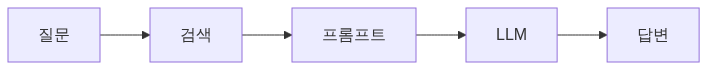

In [7]:
# LCEL 구조를 그림으로 — 한 방향 직선, 기억 없음
lcel_diagram = """flowchart LR
    Q[질문] --> R[검색] --> P[프롬프트] --> L[LLM] --> A[답변]"""
show_concept(lcel_diagram, "LCEL: 한 방향 직선 (1회 실행, 기억 없음)")

## 5-2. LangGraph — 대화를 기억하는 챗봇

LCEL은 앞 대화를 모릅니다. LangGraph는 상태(state)에 대화를 쌓아 기억합니다.
노드 두 개(retrieve → generate)를 잇고, `thread_id` 별로 대화를 따로 저장합니다.

In [8]:
# LangGraph — 상태(State)를 노드들이 주고받는 그래프로 챗봇을 만든다
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# State: 그래프가 들고 다니는 메모리.
#   MessagesState 를 상속하면 messages(대화 이력)가 자동 관리되고, context 를 하나 더 얹었다
class State(MessagesState):
    context: str

def retrieve(state):
    # 노드 1: 마지막 사용자 메시지로 검색해 context 에 담는다
    docs = retriever.invoke(state["messages"][-1].content)
    return {"context": join_docs(docs)}          # 반환한 키만 상태에 갱신된다

def generate(state):
    # 노드 2: 검색 결과(context) + 지금까지의 대화 전체를 주고 답을 생성한다
    system = SystemMessage(content="너는 저출생 정책 도우미야. 아래 맥락으로 답해.\n\n" + state["context"])
    return {"messages": [llm.invoke([system] + state["messages"])]}

# 노드를 등록하고 화살표(엣지)로 잇는다: START → retrieve → generate → END
builder = StateGraph(State)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)
# MemorySaver: thread_id 별로 대화를 저장하는 체크포인터 — 멀티턴 기억의 핵심
chatbot = builder.compile(checkpointer=MemorySaver())
print("그래프 완성")

그래프 완성


### 잠깐 — `return {"context": ...}` 만 했는데 왜 대화는 안 사라지지?

**State 를 칸이 두 개인 화이트보드라고 생각하세요.**

```
┌─────────────┬──────────────────┐
│  messages   │     context      │
│ (대화 내용) │   (검색 결과)    │
└─────────────┴──────────────────┘
```

노드가 `return {"context": ...}` 하는 것 = **화이트보드의 `context` 칸에 글씨를 적는 것** 입니다.
(여기서 "적는다 / 쓴다" 는 곧 노드가 그 값을 반환한다는 뜻이에요.)

`retrieve` 노드는 `context` 칸에만 적습니다:

```
retrieve 가 반환:  {"context": "150→250만원..."}
```

이때 **적어낸 칸(`context`)만 바뀌고, 안 적은 칸(`messages`)은 그대로 남습니다.**
화이트보드에서 한 칸만 지우고 새로 써도, 옆 칸 글씨는 안 지워지는 것과 똑같아요.

```
retrieve 실행 전:   messages = [질문]        context = (비어있음)
retrieve 실행 후:   messages = [질문]        context = 150→250만원...
                       └ 안 건드림               └ 여기만 새로 적음
```

**왜 이렇게 만들었을까?** → 노드마다 자기 일만 하게 하려고요.
`retrieve` 는 검색만, `generate` 는 답 만들기만 담당합니다.
그래서 각자 **자기가 바꿀 칸만** 적어내면 되고, 나머지 칸은 신경 안 써도 됩니다.

---

### 그럼 `generate` 노드는?

`retrieve` 가 `context` 칸에 자료를 적어놨죠. `generate` 는 **그 칸을 읽어서 답을 만드는** 노드입니다.

```python
def generate(state):
    system = SystemMessage(content="너는 저출생 정책 도우미야. 아래 맥락으로 답해.\n\n" + state["context"])
    return {"messages": [llm.invoke([system] + state["messages"])]}
```

- **첫 줄**: LLM 에게 줄 지시서를 만듭니다. `"너는 저출생 정책 도우미야..."`(역할) + `context` 칸의 검색 자료를
  하나로 붙여, "이 자료 안에서만 답해" 라고 못박습니다.
- **둘째 줄**: `[지시서] + 대화 전체` 를 통째로 LLM 에 넘겨(`llm.invoke`) 답을 받아, `messages` 칸에 적습니다.
  대화 전체를 같이 넘기기 때문에 "방금 그 금액만 숫자로" 같은 질문에도 앞 내용을 기억하고 답할 수 있어요.

**여기서 한 가지가 다릅니다.** `context` 칸은 새 값으로 **갈아끼웠지만**, `messages` 칸은
**덮어쓰지 않고 뒤에 이어붙입니다**(질문 → 답변 → 다음 질문 → 다음 답변... 이렇게 쌓여야 대화니까요).
`messages` 칸만 "덮어쓰지 말고 쌓아라" 라는 규칙이 붙어 있어서예요 — 위에서 `MessagesState` 를 상속한 덕분입니다.
(그래서 답 하나여도 `[답변]` 처럼 리스트로 감싸 건넵니다. "쌓기" 는 리스트 단위로 이뤄지거든요.)

> 한 줄 요약: `retrieve` 는 `context` 칸을 **갈아끼우고**, `generate` 는 `messages` 칸에 답을 **쌓는다.**
> 두 노드는 서로를 직접 부르지 않고, 화이트보드(State)를 사이에 두고 자료를 주고받는다.


LangGraph: 상태 그래프 (멀티턴 기억, 분기·반복)


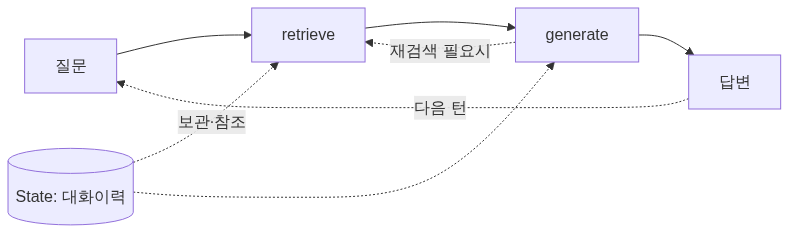

In [9]:
# LangGraph 구조를 그림으로 — 상태를 공유하는 노드들
langgraph_diagram = """flowchart LR
    Q[질문] --> RT[retrieve] --> G[generate] --> A[답변]
    S[(State: 대화이력)] -. 보관·참조 .-> RT
    S -.-> G
    G -. 재검색 필요시 .-> RT
    A -. 다음 턴 .-> Q"""
show_concept(langgraph_diagram, "LangGraph: 상태 그래프 (멀티턴 기억, 분기·반복)")

In [10]:
# 멀티턴 시험 — 두 번째 질문("방금 그 금액")은 앞 대화를 기억해야만 답할 수 있다
config = {"configurable": {"thread_id": "demo"}}     # 같은 thread_id = 같은 대화방
for question in ["육아휴직 급여 상한은 얼마로 인상돼?", "방금 그 금액만 숫자로 다시 말해줘"]:
    out = chatbot.invoke({"messages": [HumanMessage(content=question)]}, config)
    print("Q:", question)
    print("A:", out["messages"][-1].content, "\n")

Q: 육아휴직 급여 상한은 얼마로 인상돼?
A: 육아휴직 급여 상한은 현행 150만원에서 최대 250만원으로 인상됩니다. 

Q: 방금 그 금액만 숫자로 다시 말해줘
A: 250만원 



## 5-3. ReAct — 도구를 스스로 골라 쓰는 에이전트

여러 도구를 쥐고 지금 검색이 필요한지, 계산이 필요한지 스스로 판단합니다.
여기서는 정책 검색과 계산기, 두 도구를 줍니다.

In [11]:
# ReAct 에이전트 — LLM에게 도구 2개를 쥐여 주고 언제 쓸지 스스로 정하게 한다
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def search_policy(query: str) -> str:
    """저출생 대책 문서에서 관련 내용을 찾는다. 정책/숫자/제도 질문에 사용."""
    # 위 docstring 이 LLM에게 보여지는 "도구 설명서"다 — 이걸 읽고 쓸지 말지 결정한다
    return join_docs(retriever.invoke(query))

# 계산기 도구 — eval() 은 임의 코드를 실행할 수 있어 위험하므로,
# 수식을 AST(구문 트리)로 해석해 사칙연산만 허용하는 안전한 방식을 쓴다
import ast, operator
_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
        ast.Div: operator.truediv, ast.Pow: operator.pow,
        ast.Mod: operator.mod, ast.USub: operator.neg}

def _calc(node):
    # 구문 트리를 재귀적으로 계산한다 — 숫자·사칙연산 외에는 전부 거부
    if isinstance(node, ast.Constant):
        return node.value                          # 숫자 그 자체
    if isinstance(node, ast.BinOp):
        return _OPS[type(node.op)](_calc(node.left), _calc(node.right))   # a + b 꼴
    if isinstance(node, ast.UnaryOp):
        return _OPS[type(node.op)](_calc(node.operand))                   # -a 꼴
    raise ValueError("허용되지 않은 식")

@tool
def calculator(expression: str) -> str:
    """사칙연산 계산기. 예: (250-150)/150*100. 숫자와 + - * / % ** 만 가능."""
    return str(_calc(ast.parse(expression, mode="eval").body))

# create_react_agent: "생각 → 도구 호출 → 결과 관찰" 루프가 미리 구현된 에이전트
agent = create_react_agent(llm, [search_policy, calculator])
print("에이전트 준비 (도구: search_policy, calculator)")

에이전트 준비 (도구: search_policy, calculator)


ReAct: agent ⇄ tools 루프 (도구 선택을 LLM이 결정)


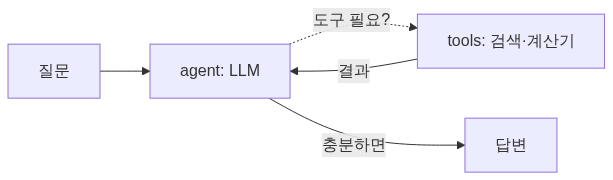

In [12]:
# ReAct 구조를 그림으로 — 에이전트와 도구 사이의 루프
react_diagram = """flowchart LR
    Q[질문] --> AG[agent: LLM]
    AG -. 도구 필요? .-> T[tools: 검색·계산기]
    T -- 결과 --> AG
    AG -- 충분하면 --> A[답변]"""
show_concept(react_diagram, "ReAct: agent ⇄ tools 루프 (도구 선택을 LLM이 결정)")

### 추론 과정 들여다보기

ReAct는 생각 → 도구 호출 → 결과 관찰을 반복합니다. `stream()` 으로 단계별 메시지를 찍어 봅니다.

In [13]:
# stream() 으로 에이전트의 중간 과정(도구 호출 → 결과 → 최종 답)을 단계별로 본다
question = "육아휴직 급여 상한은 얼마로 오르고, 인상 전 대비 몇 % 올라?"
for step in agent.stream({"messages": [("user", question)]}, stream_mode="values"):
    step["messages"][-1].pretty_print()          # 각 단계의 마지막 메시지를 보기 좋게 출력

================================ Human Message =================================

육아휴직 급여 상한은 얼마로 오르고, 인상 전 대비 몇 % 올라?
================================== Ai Message ==================================
Tool Calls:
  search_policy (call_5wh4CbdHH39XgS5GgYDMT0o0)
 Call ID: call_5wh4CbdHH39XgS5GgYDMT0o0
  Args:
    query: 육아휴직 급여 상한
  search_policy (call_g6Ko3MKcBSBHp7uaQS110I2A)
 Call ID: call_g6Ko3MKcBSBHp7uaQS110I2A
  Args:
    query: 육아휴직 급여 인상 전 대비 퍼센트
================================= Tool Message =================================
Name: search_policy

이 청크는 육아휴직 급여와 관련된 개선 방안 및 제도 활용도를 높이기 위한 규제 개선 내용에 대해 설명하고 있다.

## 현행

- 통상임금 80%(月150만원 상한)
- → 최대 1년간 매월 균등 지급
- 1년 휴직 시, 총 급여 상한 1,800만원

## 개선(예시)

- 초기 3개월(통상임금 100%, 月250만원 상한)
+ 이후 3개월(통상임금 100%, 月200만원 상한)
+ 이후 6개월(통상임금  80%, 月160만원 상한)
- 1년 휴직시, 총 급여 상한 2,310만원
- ➎ (사후지급금 폐지) 육아휴직급여의 25% 를 복직 후 6 개월 이상 계속 근로 시 지급하는 사후지급금을 폐지하여 소득대체율을 인상 ( 고용부 )
-  임신·육아기 근로시간 단축제도 활용 여건 개선
- ➊ (규제  개선) 현장 의견 등을 반영하여 임신 · 육아기 근로시간 단축 제도의 실질적인 활

### 활용 예시 다섯 가지

같은 에이전트가 질문 성격에 따라 도구를 안 쓰거나, 검색하거나, 계산하거나, 둘 다 쓰거나, 거절합니다.

In [14]:
# 성격이 다른 질문 5개 — 에이전트가 도구를 골라 쓰는 판단을 관찰한다
examples = [
    "안녕! 너 뭐 할 수 있어?",                                      # 도구 불필요
    "신생아 특례대출 소득요건은 얼마로 완화돼?",                     # 검색 필요
    "(250-150)/150*100 계산해줘",                                    # 계산 필요
    "육아휴직 급여 상한은 얼마로 오르고, 인상 전 대비 몇 % 올라?",   # 검색 + 계산
    "오늘 서울 날씨 어때?",                                          # 도구가 없는 영역 → 거절
]
for question in examples:
    out = agent.invoke({"messages": [("user", question)]})
    # 대화 기록을 뒤져 이번에 호출된 도구 이름을 모은다
    used = [tc["name"] for m in out["messages"] for tc in (getattr(m, "tool_calls", None) or [])]
    print("Q:", question)
    print("도구:", used or "없음")
    print("A:", out["messages"][-1].content[:200], "\n")

Q: 안녕! 너 뭐 할 수 있어?
도구: 없음
A: 안녕하세요! 저는 다양한 질문에 답변하고, 정보 검색, 계산, 정책 관련 내용 찾기 등을 도와드릴 수 있습니다. 궁금한 점이나 필요한 정보가 있으면 말씀해 주세요! 

Q: 신생아 특례대출 소득요건은 얼마로 완화돼?
도구: ['search_policy']
A: 신생아 특례 대출의 소득 요건이 완화되었습니다. 구체적으로, 신생아 특례 구입 및 전세자금 대출의 소득 요건이 1.3억 원에서 2억 원으로, 그리고 2025년 이후 출산한 가구에 대해서는 2억 원에서 2.5억 원으로 추가 완화됩니다. 이 조치는 3년간 한시적으로 시행됩니다. 

Q: (250-150)/150*100 계산해줘
도구: ['calculator']
A: 계산 결과는 약 66.67입니다. 

Q: 육아휴직 급여 상한은 얼마로 오르고, 인상 전 대비 몇 % 올라?
도구: ['search_policy', 'search_policy']
A: 육아휴직 급여 상한은 다음과 같이 인상됩니다:

- **인상 전**: 월 150만원
- **인상 후**: 월 250만원

따라서, 급여 상한이 **100만원** 인상되었습니다.

인상 전 대비 인상 비율은 다음과 같이 계산할 수 있습니다:

\[
\text{인상 비율} = \left( \frac{\text{인상 후} - \text{인상 전}}{\text{인 

Q: 오늘 서울 날씨 어때?
도구: 없음
A: 죄송하지만, 현재 날씨 정보를 제공할 수 없습니다. 서울의 날씨를 확인하려면 기상청 웹사이트나 날씨 앱을 이용해 주세요. 



## 5-4. 세 방식 비교

| | LCEL | LangGraph | ReAct |
|---|---|---|---|
| 구조 | 직선 파이프 | 상태 그래프 | 도구 루프 |
| 대화 기억 | 없음 | 있음 | 있음 |
| 분기·반복 | 없음 | 직접 설계 | LLM이 결정 |
| 검색/도구 | 항상 검색 | 항상 검색 | 필요할 때 골라서 |

LCEL에서 LangGraph로 가면 직선이 상태 그래프가 되어 기억·분기·반복이 가능해집니다.
LangGraph에서 ReAct로 가면 흐름을 사람이 짜는 대신 LLM이 도구 호출을 스스로 결정합니다.

## 직접 해보기

> 예시 코드를 **새 셀에 복사해** 실행해 보세요.

**1. ReAct `examples` 에 질문을 더 넣어 어떤 도구를 고르는지 보세요.**
```python
out = agent.invoke({"messages": [("user", "육아휴직급여 총 상한이 1800만원에서 2310만원이 되면 몇 % 오르는 거야?")]})
used = [tc["name"] for m in out["messages"] for tc in (getattr(m, "tool_calls", None) or [])]
print("도구:", used or "없음")
print("답변:", out["messages"][-1].content[:200])
```

**2. 새 도구(@tool)를 하나 더 만들어 에이전트에 추가해 보세요.** (예: 오늘 날짜 — 완성 예시는 아래 심화에 있습니다)

**3. LangGraph에 검색 결과가 충분한지 판단하는 노드를 넣어 흐름을 바꿔 보세요.**
```python
# 뼈대 예시 — retrieve 와 generate 사이에 점검 노드를 끼워 넣습니다
def grade(state):
    if len(state["context"]) < 100:                       # 검색 결과가 너무 짧으면
        return {"context": state["context"] + "\n(참고: 검색 결과가 부족합니다. 모르면 모른다고 답하세요.)"}
    return {}

builder2 = StateGraph(State)
builder2.add_node("retrieve", retrieve)
builder2.add_node("grade", grade)
builder2.add_node("generate", generate)
builder2.add_edge(START, "retrieve")
builder2.add_edge("retrieve", "grade")                    # retrieve → grade → generate 로 배선
builder2.add_edge("grade", "generate")
builder2.add_edge("generate", END)
chatbot2 = builder2.compile(checkpointer=MemorySaver())

out = chatbot2.invoke({"messages": [HumanMessage(content="육아휴직 급여 상한은 얼마로 인상돼?")]},
                      {"configurable": {"thread_id": "grade-test"}})
print(out["messages"][-1].content[:100])
```

## 시간이 남으면 (심화) — 도구 하나 더 만들어 끼우기

새 도구를 만드는 데 필요한 것은 세 가지뿐입니다.

1. `@tool` 데코레이터를 붙인 함수
2. **docstring** — LLM은 이 설명을 읽고 도구를 쓸지 결정합니다 (이름보다 중요!)
3. `create_react_agent(llm, [...])` 도구 목록에 추가

'오늘 날짜' 도구를 만들어, 에이전트가 검색·계산·날짜를 골라 쓰는지 확인합니다.

In [15]:
# 새 도구 만들기 완성 예시 — 함수 + docstring + 도구 목록 추가, 이 세 가지가 전부다
from datetime import date

@tool
def today() -> str:
    """오늘 날짜를 YYYY-MM-DD 형식으로 알려준다. 날짜·요일·기간 계산 질문에 사용."""
    return date.today().isoformat()

# 도구 3개짜리 에이전트를 새로 만든다 (기존 agent 는 그대로 두고)
agent2 = create_react_agent(llm, [search_policy, calculator, today])

for question in [
    "오늘 며칠이야?",
    "오늘 날짜 기준으로, 2025년 시행 예정인 신생아 특례대출 소득요건 완화까지 몇 년 남았어?",
]:
    out = agent2.invoke({"messages": [("user", question)]})
    used = [tc["name"] for m in out["messages"] for tc in (getattr(m, "tool_calls", None) or [])]
    print("Q:", question)
    print("도구:", used or "없음")
    print("A:", out["messages"][-1].content[:150], "\n")

# 여러분 차례 — 어떤 도구가 있으면 좋을까? (단위 환산, 문서 요약, 영어 번역...)
#    함수 하나 + docstring 한 줄이면 에이전트의 능력이 하나 늘어난다.

Q: 오늘 며칠이야?
도구: ['today']
A: 오늘은 2026년 7월 11일입니다. 

Q: 오늘 날짜 기준으로, 2025년 시행 예정인 신생아 특례대출 소득요건 완화까지 몇 년 남았어?
도구: ['today', 'calculator']
A: 오늘 날짜는 2026년 7월 11일입니다. 따라서 2025년에 시행 예정인 신생아 특례대출 소득요건 완화는 이미 시행된 상태입니다. 



## 정리
- 셋 다 같은 검색기를 씁니다. 앞 세션의 검색 품질이 챗봇 품질의 바탕입니다.
- 구조로 보면 LCEL은 직선, LangGraph는 그래프, ReAct는 도구 루프입니다.
- 도구는 함수 하나 + docstring 한 줄로 늘릴 수 있습니다(심화).
- 웹 배포는 `poetry run streamlit run app/streamlit_app.py` 입니다.